In [1]:
import monai 
from script_EVAL_fm import *
import json 


json_files = "config_EVAL_fm.json"
args = build_args_from_path(json_files)
encoder= define_instance(args,"encoder")
#encoder.load_state_dict(torch.load("model_encoder.pth"))
diff_unet = define_instance(args,"diff_unet")
#diff_unet.load_state_dict(torch.load("model_diff_unet.pth"))
noise_scheduler = define_instance(args,"noise_scheduler")
upscaler = define_instance(args,"upscaler")
device = define_instance(args,"device")
inferer = define_instance(args,"inferer")
dito = DiffusionModelWrapper(
    encoder=encoder,
    diff_unet=diff_unet,
    noise_scheduler=noise_scheduler,
    upscaler=upscaler,
    loss_fn=torch.nn.MSELoss(),
)
dito.to(device)

if False:
    encoder.load_state_dict(torch.load("model_encoder.pth"))
    diff_unet.load_state_dict(torch.load("model_diff_unet.pth"))
else:
    dito.load_state_dict(torch.load("dito.pth"))

/tmp/ipykernel_3955735/2963370475.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dito.load_state_dict(torch.load("dito.pth"))


In [2]:
data_root = "/data4/brats25/brats2025_07_30_buildfromzero_for_project_brats25/ZHANGYUXUAN_SYN_ADNI/ADNI_1"
import glob
import os 
import torchio as tio 
data_list =sorted(glob.glob(os.path.join(data_root,"*.nii*")))
data_list = [{"image":d} for d in data_list]
total_length = len(data_list)
train_list, val_list,test_list = data_list[:int(total_length*0.8)],data_list[int(total_length*0.8):int(total_length*0.9)],data_list[int(total_length*0.9):]
print(len(train_list),len(val_list),len(test_list))
from maisi_vae_transform import define_mri_vae_transform


1421 178 178


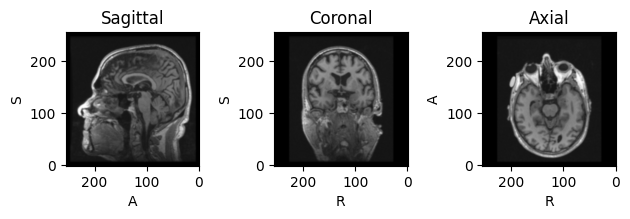

In [3]:
transform = define_mri_vae_transform(
    is_train=False,
    random_aug=True,
    val_patch_size=(256,256,256),
    spacing_type="fixed",
    spacing=(1.0,1.0,1.0),
    image_keys=["image"],
)
train_dataset = monai.data.Dataset(train_list,transform)
dataloader = monai.data.DataLoader(train_dataset, batch_size=1, num_workers=8, shuffle=False, drop_last=False)
batch = next(iter(dataloader))
image = batch["image"].to(device)
tio.ScalarImage(tensor=image[0]).plot()

In [4]:
#args.inferer["roi_size"]=[16,16,16]
inferer = define_instance(args,"inferer")
latent_dir = "/data4/brats25/dito_2d3d_demo/demos/demos_data/data_for_exp_1_basic_copy_infer"
if len(glob.glob(latent_dir+"/*.pt"))>=len(train_list):
    print("latent_dir already exists")
else:
    os.makedirs(latent_dir,exist_ok=True)
    with torch.no_grad(), torch.cuda.amp.autocast():
        for batch in tqdm(dataloader):
            image = batch["image"].to(device)
            latent = inferer (inputs=image,network=dito.encode)
            basename = os.path.basename(image.meta["filename_or_obj"][0]).replace(".gz","").replace(".nii",".pt")
        basename = "latent_"+basename
        filename = os.path.join(latent_dir,basename)
        torch.save(latent,filename)
        
# args.inferer["roi_size"]=[16,16,16]
# inferer_recon = define_instance(args,"inferer")
# with torch.no_grad(), torch.cuda.amp.autocast():
#     latent = glob.glob(latent_dir+"/*.pt")[0]
#     latent = torch.load(latent).to(next(iter(dito.parameters())).device)
#     recon  = inferer_recon(
#         inputs=latent.float(),
#         network=dito.decode,
#     )    

latent_dir already exists


In [5]:
latent = sorted(glob.glob(latent_dir+"/*.pt")[0])

In [6]:
import pandas as pd
from pprint import pprint
from IPython.display import display

# Define the categorization function with improved logic
def categorize_terms(terms_list):
    """
    Categorizes a list of medical/research terms based on predefined keywords.

    Args:
        terms_list (list): A list of strings, where each string is a term to categorize.

    Returns:
        dict: A dictionary where keys are category names and values are lists of terms
              belonging to that category.
    """
    # Clean and get unique terms to avoid duplicate processing and ensure neat output
    cleaned_terms = [term.strip() for term in terms_list if term.strip()]
    unique_terms = sorted(list(set(cleaned_terms))) # Sort for consistent output order

    # Initialize categories dictionary
    categories = {
        "Study and Participant Identifiers": [],
        "Demographics and Baseline Characteristics": [],
        "Longitudinal Data/Time Points": [],
        "Biomarkers": [], # Renamed for clarity (includes CSF and PET)
        "Everyday Cognition (ECog) Questionnaires": [],
        "Cognitive Assessments (Scores/Scales)": [],
        "Neuroimaging": [], # Renamed for clarity
        "Uncategorized": [] # To catch any terms that don't fit into defined categories
    }

    # Define keywords for each category.
    # IMPORTANT: The order of 'if/elif' checks in the loop below is crucial for correct classification.
    # More specific categories should be checked first.
    category_keywords = {
        "Everyday Cognition (ECog) Questionnaires": ["ecogpt", "ecogsp", "ecog"],
        "Biomarkers": ["abeta", "tau", "ptau", "fdg", "pib", "av45", "fbb"],
        "Neuroimaging": [
            "ucsf", "ventricles", "hippocampus", "wholebrain", "entorhinal", "fusiform",
            "midtemp", "icv", 
            "fldstreng", 
            #"fsversion", #"imageuid",
            "mri", "pet", "suvr" # General terms, but specific enough in context
        ],
        "Cognitive Assessments (Scores/Scales)": [
            "cdr", "adas", "mmse", "ravlt", "faq", "moca", "pacc",
            "digitscor", "trabscor", "ldeltotal", "adasq4",
            "recall", "learning", "forgetting", "composite"
        ],
        "Longitudinal Data/Time Points": ["month", "m"], # Only explicit time components for longitudinal
        "Study and Participant Identifiers": ["rid", "colprot", "origprot", "ptid", "site", "viscode", "update_stamp"],
        "Demographics and Baseline Characteristics": [
            "dx", "examdate", "age", "ptgender", "pteducat", "ptethcat", "ptraccat", "ptmarry", "apoe4"
        ]
    }

    # Process each unique term
    for term in unique_terms:
        lower_term = term.lower()
        assigned = False

        # Apply checks in order of specificity/priority
        if any(keyword in lower_term for keyword in category_keywords["Everyday Cognition (ECog) Questionnaires"]):
            categories["Everyday Cognition (ECog) Questionnaires"].append(term)
            assigned = True
        elif any(keyword in lower_term for keyword in category_keywords["Biomarkers"]):
            categories["Biomarkers"].append(term)
            assigned = True
        elif any(keyword in lower_term for keyword in category_keywords["Neuroimaging"]):
            categories["Neuroimaging"].append(term)
            assigned = True
        elif any(keyword in lower_term for keyword in category_keywords["Cognitive Assessments (Scores/Scales)"]):
            categories["Cognitive Assessments (Scores/Scales)"].append(term)
            assigned = True
        elif any(keyword in lower_term for keyword in category_keywords["Longitudinal Data/Time Points"]):
            categories["Longitudinal Data/Time Points"].append(term)
            assigned = True
        elif any(keyword in lower_term for keyword in category_keywords["Study and Participant Identifiers"]):
            categories["Study and Participant Identifiers"].append(term)
            assigned = True
        elif any(keyword in lower_term for keyword in category_keywords["Demographics and Baseline Characteristics"]):
            categories["Demographics and Baseline Characteristics"].append(term)
            assigned = True
        else:
            categories["Uncategorized"].append(term)

    # Sort terms within each category alphabetically for clean output
    for category in categories:
        categories[category] = sorted(list(set(categories[category])))

    return categories

# --- Your DataFrame processing begins here ---
df = pd.read_csv("/data4/brats25/dito_2d3d_demo/demos/exp_1_basic_copy/ADNIMERGE_03Aug2025.csv")

# Filter out columns ending with "_bl" as per your instruction
df = df.drop(columns=[c for c in df.columns if c.endswith("_bl")])

# Select only first visit data, sort by EXAMDATE for each PTID
df = df.sort_values(by=["PTID","EXAMDATE"])
df = df.drop_duplicates(subset=["PTID"],keep="first")

# Get the current columns of the filtered DataFrame
df_columns_array = df.columns.values

# Convert the numpy array to a list for categorization
terms_list_for_categorization = df_columns_array.tolist()

# Categorize the terms
categorized_df_columns = categorize_terms(terms_list_for_categorization)

print("--- Categorization of Current DataFrame Columns (after filtering '_bl' and first visit) ---")
display(categorized_df_columns) # Print the raw categorization dictionary for verification


# --- Now, integrate categories into the completeness DataFrame ---

# Compute completeness for each column
completeness = (df.notnull().sum() / len(df)) * 100
completeness_df = pd.DataFrame({'Column': completeness.index, 'Completeness (%)': completeness.values})
completeness_df = completeness_df.sort_values(by='Completeness (%)', ascending=False).reset_index(drop=True)


# Create a mapping dictionary from column name to its category
column_to_category_map = {}
for category, terms_in_category in categorized_df_columns.items():
    for term in terms_in_category:
        column_to_category_map[term] = category

# Add a 'Category' column to the completeness_df using the mapping
completeness_df['Category'] = completeness_df['Column'].map(column_to_category_map)

# Handle potential NaNs in 'Category' if some columns weren't categorized
completeness_df['Category'].fillna('Uncategorized', inplace=True)


print("\n--- Detailed Completeness with Categorization ---")
# Display the combined DataFrame
display(completeness_df)

df = pd.read_csv("/data4/brats25/dito_2d3d_demo/demos/exp_1_basic_copy/ADNIMERGE_03Aug2025.csv")

# Filter out columns ending with "_bl" as per your instruction
df = df.drop(columns=[c for c in df.columns if c.endswith("_bl")])

# Select only first visit data, sort by EXAMDATE for each PTID
df = df.sort_values(by=["PTID","EXAMDATE"])
df = df.drop_duplicates(subset=["PTID"],keep="first")

id_column_types = [
    'Study and Participant Identifiers',
    "Demographics and Baseline Characteristics",   
    ]
id_columns = [column for id_column_type in id_column_types for column in categorized_df_columns[id_column_type]]
scan_column_types = [
    'Neuroimaging',
]
scan_columns = [column for scan_column_type in scan_column_types for column in categorized_df_columns[scan_column_type]]
GT_column_types = [
    'Biomarkers',
]
GT_columns = [column for GT_column_type in GT_column_types for column in categorized_df_columns[GT_column_type]]
cognition_column_types=[
    "Everyday Cognition (ECog) Questionnaires",
    'Cognitive Assessments (Scores/Scales)',
]
cognition_columns = [column for cognition_column_type in cognition_column_types for column in categorized_df_columns[cognition_column_type]]
drop_column_types = [
    'Longitudinal Data/Time Points',
    'Uncategorized'
]
drop_columns = [column for drop_column_type in drop_column_types for column in categorized_df_columns[drop_column_type]]
columns_total = [
    id_columns,
    scan_columns,
    GT_columns,
    cognition_columns,
    drop_columns,
]

for columns in columns_total:
    display(completeness_df[completeness_df["Column"].isin(columns)].reset_index(drop=True))


--- Categorization of Current DataFrame Columns (after filtering '_bl' and first visit) ---


/tmp/ipykernel_3955735/2352892935.py:95: DtypeWarning: Columns (19,20,21,50,51,104,105,106) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/data4/brats25/dito_2d3d_demo/demos/exp_1_basic_copy/ADNIMERGE_03Aug2025.csv")


{'Study and Participant Identifiers': ['COLPROT',
  'ORIGPROT',
  'PTID',
  'RID',
  'SITE',
  'VISCODE'],
 'Demographics and Baseline Characteristics': ['AGE',
  'APOE4',
  'DX',
  'PTEDUCAT',
  'PTETHCAT',
  'PTGENDER',
  'PTRACCAT'],
 'Longitudinal Data/Time Points': ['EXAMDATE',
  'IMAGEUID',
  'M',
  'Month',
  'PTMARRY',
  'update_stamp'],
 'Biomarkers': ['ABETA', 'AV45', 'FBB', 'FDG', 'PIB', 'PTAU', 'TAU'],
 'Everyday Cognition (ECog) Questionnaires': ['EcogPtDivatt',
  'EcogPtLang',
  'EcogPtMem',
  'EcogPtOrgan',
  'EcogPtPlan',
  'EcogPtTotal',
  'EcogPtVisspat',
  'EcogSPDivatt',
  'EcogSPLang',
  'EcogSPMem',
  'EcogSPOrgan',
  'EcogSPPlan',
  'EcogSPTotal',
  'EcogSPVisspat'],
 'Cognitive Assessments (Scores/Scales)': ['ADAS11',
  'ADAS13',
  'ADASQ4',
  'CDRSB',
  'DIGITSCOR',
  'FAQ',
  'LDELTOTAL',
  'LDELTOTAL_BL',
  'MMSE',
  'MOCA',
  'RAVLT_forgetting',
  'RAVLT_immediate',
  'RAVLT_learning',
  'RAVLT_perc_forgetting',
  'TRABSCOR',
  'mPACCdigit',
  'mPACCtrailsB'


--- Detailed Completeness with Categorization ---


/tmp/ipykernel_3955735/2352892935.py:135: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  completeness_df['Category'].fillna('Uncategorized', inplace=True)


...

,Column,Completeness (%),Category
0,RID,100.000000,Study and Participant Identifiers
1,PTETHCAT,100.000000,Demographics and Baseline Characteristics
2,PTRACCAT,100.000000,Demographics and Baseline Characteristics
3,PTGENDER,100.000000,Demographics and Baseline Characteristics
4,PTEDUCAT,100.000000,Demographics and Baseline Characteristics
5,ORIGPROT,100.000000,Study and Participant Identifiers
6,PTID,100.000000,Study and Participant Identifiers
7,SITE,100.000000,Study and Participant Identifiers
8,VISCODE,100.000000,Study and Participant Identifiers
9,COLPROT,100.000000,Study and Participant Identifiers


,Column,Completeness (%),Category
0,ICV,96.213992,Neuroimaging
1,WholeBrain,94.320988,Neuroimaging
2,Ventricles,92.674897,Neuroimaging
3,Hippocampus,85.637860,Neuroimaging
4,Entorhinal,84.444444,Neuroimaging
5,Fusiform,84.444444,Neuroimaging
6,MidTemp,84.444444,Neuroimaging
7,FLDSTRENG,64.567901,Neuroimaging


,Column,Completeness (%),Category
0,FDG,62.345679,Biomarkers
1,ABETA,50.000000,Biomarkers
2,TAU,50.000000,Biomarkers
3,PTAU,50.000000,Biomarkers
4,AV45,46.625514,Biomarkers
5,FBB,14.238683,Biomarkers
6,PIB,0.823045,Biomarkers


,Column,Completeness (%),Category
0,CDRSB,100.000000,Cognitive Assessments (Scores/Scales)
1,MMSE,99.958848,Cognitive Assessments (Scores/Scales)
2,mPACCtrailsB,99.876543,Cognitive Assessments (Scores/Scales)
3,mPACCdigit,99.876543,Cognitive Assessments (Scores/Scales)
4,LDELTOTAL,99.835391,Cognitive Assessments (Scores/Scales)
5,LDELTOTAL_BL,99.835391,Cognitive Assessments (Scores/Scales)
6,ADASQ4,99.711934,Cognitive Assessments (Scores/Scales)
7,RAVLT_immediate,99.547325,Cognitive Assessments (Scores/Scales)
8,RAVLT_learning,99.547325,Cognitive Assessments (Scores/Scales)
9,RAVLT_forgetting,99.506173,Cognitive Assessments (Scores/Scales)


,Column,Completeness (%),Category
0,update_stamp,100.000000,Longitudinal Data/Time Points
1,EXAMDATE,100.000000,Longitudinal Data/Time Points
2,Month,100.000000,Longitudinal Data/Time Points
3,M,100.000000,Longitudinal Data/Time Points
4,PTMARRY,99.958848,Longitudinal Data/Time Points
5,IMAGEUID,96.296296,Longitudinal Data/Time Points
6,FSVERSION,96.296296,Uncategorized


In [7]:
latents = sorted(glob.glob(latent_dir+"/*.pt"))
latent_ids = [os.path.basename(latent).split(".")[0][7:] for latent in latents]
print(latent_ids[:5],latent_ids[-5:],len(latent_ids))


#display(df[["AGE","PTID","DX"]])
df = pd.read_csv("/data4/brats25/dito_2d3d_demo/demos/exp_1_basic_copy/ADNIMERGE_03Aug2025.csv")
org_df = df.copy()
df = df.drop(columns=[c for c in df.columns if c.endswith("_bl")])
df = df.sort_values(by=["PTID","EXAMDATE"])
df = df.drop_duplicates(subset=["PTID"],keep="first")
df = df.dropna(subset=["DX"])
df_latent = df[df["PTID"].isin(latent_ids)]
other_cols = ["AGE"]
display(df_latent[["PTID","DX"]+other_cols])

subject_data_map = df_latent.set_index("PTID")[["DX", "AGE"]].T.to_dict('list')
label_map = {"CN":0,"MCI":1,"Dementia":2}
# 2. Construct datalist using the efficient map
datalist = []
for latent, latent_id in zip(latents, latent_ids):
    # Check if the latent file exists and if its ID is present in our subject_data_map
    if os.path.exists(latent) and latent_id in subject_data_map:
        # Perform efficient lookup to get DX and AGE
        dx, age = subject_data_map[latent_id]
        datalist.append({
            "subject_id": latent_id,
            "image": latent,
            "labels": label_map[dx],
            "age": age,
        })

print(f"\nLengths: datalist={len(datalist)}, df_latent={len(df_latent)}, latents={len(latents)}")

print("\nFirst 3 entries of the datalist (for verification):")
pprint(datalist[:3]) # Using pprint for cleaner dictionary output



['002_S_0295', '002_S_0413', '002_S_0559', '002_S_0619', '002_S_0685'] ['128_S_4671', '128_S_4742', '128_S_4772', '128_S_4774', '128_S_4792'] 1421


/tmp/ipykernel_3955735/2385705869.py:7: DtypeWarning: Columns (19,20,21,50,51,104,105,106) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/data4/brats25/dito_2d3d_demo/demos/exp_1_basic_copy/ADNIMERGE_03Aug2025.csv")


,PTID,DX,AGE
669,002_S_0295,CN,84.8
931,002_S_0413,CN,76.3
1238,002_S_0559,CN,79.3
1333,002_S_0619,Dementia,77.5
11501,002_S_0685,CN,89.6
...,...,...,...
4383,128_S_4671,MCI,81.8
4182,128_S_4742,MCI,70.6
4096,128_S_4772,Dementia,78.7
4092,128_S_4774,Dementia,85.8



Lengths: datalist=1332, df_latent=1332, latents=1421

First 3 entries of the datalist (for verification):
[{'age': 84.8,
  'image': '/data4/brats25/dito_2d3d_demo/demos/demos_data/data_for_exp_1_basic_copy_infer/latent_002_S_0295.pt',
  'labels': 0,
  'subject_id': '002_S_0295'},
 {'age': 76.3,
  'image': '/data4/brats25/dito_2d3d_demo/demos/demos_data/data_for_exp_1_basic_copy_infer/latent_002_S_0413.pt',
  'labels': 0,
  'subject_id': '002_S_0413'},
 {'age': 79.3,
  'image': '/data4/brats25/dito_2d3d_demo/demos/demos_data/data_for_exp_1_basic_copy_infer/latent_002_S_0559.pt',
  'labels': 0,
  'subject_id': '002_S_0559'}]


In [8]:
# by hand check if EXAMDATA is earliest for each PTID
display(org_df[org_df["PTID"]=="011_S_0003"])
display(df[df["PTID"]=="011_S_0003"])
pd.DataFrame(datalist)["labels"].value_counts()

,RID,COLPROT,ORIGPROT,PTID,SITE,VISCODE,EXAMDATE,DX_bl,AGE,PTGENDER,...,PTAU_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl,Years_bl,Month_bl,Month,M,update_stamp
1,3,ADNI1,ADNI1,011_S_0003,11,bl,2005-09-12,AD,81.3,Male,...,22.83,1.1086,NaN,NaN,NaN,0.000000,0.00000,0,0,2023-07-07 04:59:40.0
2,3,ADNI1,ADNI1,011_S_0003,11,m06,2006-03-13,AD,81.3,Male,...,22.83,1.1086,NaN,NaN,NaN,0.498289,5.96721,6,6,2023-07-07 04:59:40.0
3,3,ADNI1,ADNI1,011_S_0003,11,m12,2006-09-12,AD,81.3,Male,...,22.83,1.1086,NaN,NaN,NaN,0.999316,11.96720,12,12,2023-07-07 04:59:40.0
4,3,ADNI1,ADNI1,011_S_0003,11,m24,2007-09-12,AD,81.3,Male,...,22.83,1.1086,NaN,NaN,NaN,1.998630,23.93440,24,24,2023-07-07 04:59:40.0
5114,3,ADNI1,ADNI1,011_S_0003,11,m18,2007-03-12,AD,81.3,Male,...,22.83,1.1086,NaN,NaN,NaN,1.494870,17.90160,18,18,2023-07-07 04:59:40.0


,RID,COLPROT,ORIGPROT,PTID,SITE,VISCODE,EXAMDATE,AGE,PTGENDER,PTEDUCAT,...,Fusiform,MidTemp,ICV,DX,mPACCdigit,mPACCtrailsB,LDELTOTAL_BL,Month,M,update_stamp
1,3,ADNI1,ADNI1,011_S_0003,11,bl,2005-09-12,81.3,Male,18,...,15506.0,18422.0,1920690.0,Dementia,-16.2449,-15.8299,2.0,0,0,2023-07-07 04:59:40.0


labels
1    627
0    473
2    232
Name: count, dtype: int64

In [9]:
transform = lambda x: torch.load(x,map_location="cpu")[0].float()
#transform(datalist[0]).shape
import monai.data as md
import monai.transforms as mt
dataset = md.Dataset(datalist,transform=mt.Lambdad(keys=["image"],func=transform))
dataloader = md.ThreadDataLoader(dataset,batch_size=1,shuffle=False)

for batch in tqdm(dataloader):
    pass

  0%|          | 0/1332 [00:00<?, ?it/s]/tmp/ipykernel_3955735/1362392670.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transform = lambda x: torch.load(x,map_location

In [10]:
from script_EVAL_fm import VaeEncoder,DiffusionDecoder,ConditionalFlowMatching,LatentConditionalFlowMatching
from monai.inferers import DiffusionInferer

eval_cond_diff_arg_path = "config_EVAL_fm_cond_diff_args.json"
TRAIN_START = not os.path.exists(eval_cond_diff_arg_path)
model_path = eval_cond_diff_arg_path.replace(".json","_pipeline.pt")
TRAIN_FINISHED = os.path.exists(model_path)

if TRAIN_START:
    print(f"json {os.path.abspath(eval_cond_diff_arg_path)} not found, start new train")
    args = build_args_from_path("/data4/brats25/dito_2d3d_demo/demos/exp_1_basic/exp_1.json")
    cond_diff_unet = args.diff_unet.copy()
    cond_diff_unet["in_channels"]=4
    cond_diff_unet["out_channels"]=4
    cond_diff_unet["cross_attention_dim"]=16
    cond_diff_unet["with_conditioning"]=True
    setattr(args,"cond_diff_unet",cond_diff_unet)

    import json 
    with open(eval_cond_diff_arg_path,"w") as f:
        json.dump(args.__dict__,f,indent=4)
    pprint(f"save new json to {os.path.abspath(eval_cond_diff_arg_path)}")
    pprint(args.__dict__)
else:
    args = build_args_from_path(eval_cond_diff_arg_path)
    print(f"load json from {os.path.abspath(eval_cond_diff_arg_path)}")
    print("*"*100)
    pprint(args.__dict__)
    print("*"*100)
    TRAIN_FINISHED=False

vae_encoder = VaeEncoder(encoder)
diffusion_decoder = DiffusionDecoder(diff_unet,noise_scheduler,upscaler)

diff_inferer = DiffusionInferer(scheduler=noise_scheduler)

cond_diff_unet = define_instance(args,"cond_diff_unet")

# pipeline = ConditionalFlowMatching(
#     encoder= vae_encoder,
#     diffusion_model=cond_diff_unet,
#     inferer=diff_inferer,
#     decoder= diffusion_decoder,
#     num_class=3,
# )
pipeline = LatentConditionalFlowMatching(
    encoder= vae_encoder,
    diffusion_model=cond_diff_unet,
    inferer=diff_inferer,
    decoder= diffusion_decoder,
    num_class=3,
)

if TRAIN_FINISHED:
    print(f"loading existing model from {os.path.abspath(model_path)}")
    print("train will not start, will do inference only")
    pipeline.load_state_dict(torch.load(model_path))
else:
    print(f"WIll start train model in {os.path.abspath(model_path)}")


try:
    pipeline.label_embed(torch.randint(0,5,(100,))) # 3 class + 1 uncond  = 0,1,2,3  randint : 0,1,2,3,4  4 is not allowed 
except:
    print("Red Tests pass!")
    print("# 3 class + 1 uncond  = 0,1,2,3  randint : 0,1,2,3,4  4 is not allowed ")

load json from /data4/brats25/dito_2d3d_demo/demos/exp_1_basic_copy/EVAL_cond_diff/ADNI/config_EVAL_fm_cond_diff_args.json
****************************************************************************************************
{'channels': [64, 128, 256],
 'cond_diff_unet': {'_target_': 'monai.networks.nets.DiffusionModelUNet',
                    'attention_levels': [False, False, True],
                    'channels': '@channels',
                    'cross_attention_dim': 16,
                    'in_channels': 4,
                    'norm_eps': '@norm_eps',
                    'norm_num_groups': '@norm_num_groups',
                    'num_head_channels': 64,
                    'num_res_blocks': '@num_res_blocks',
                    'out_channels': 4,
                    'spatial_dims': '@spatial_dims',
                    'use_flash_attention': True,
                    'with_conditioning': True},
 'device': 'cuda',
 'diff_unet': {'_target_': 'monai.networks.nets.DiffusionModelUNet'

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
if not TRAIN_FINISHED :
    print("starting new train ")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
    pipeline = LatentConditionalFlowMatching(vae_encoder,diff_inferer,cond_diff_unet,diffusion_decoder)
    pipeline.to("cuda")
    optimizer = torch.optim.Adam(pipeline.parameters(), lr=1e-4)

    # To store loss values for plotting
    loss_history = [] 
else:
    print("train will not start ")



starting new train 


/tmp/ipykernel_3955735/2585682668.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


Starting training...


/tmp/ipykernel_3955735/1362392670.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transform = lambda x: torch.load(x,map_location="cpu")[0].float()
/tmp/ipykernel_395573

Epoch [1/100], Step [0/1332], Loss: 2.0222


100%|██████████| 25/25 [00:00<00:00, 59.77it/s]


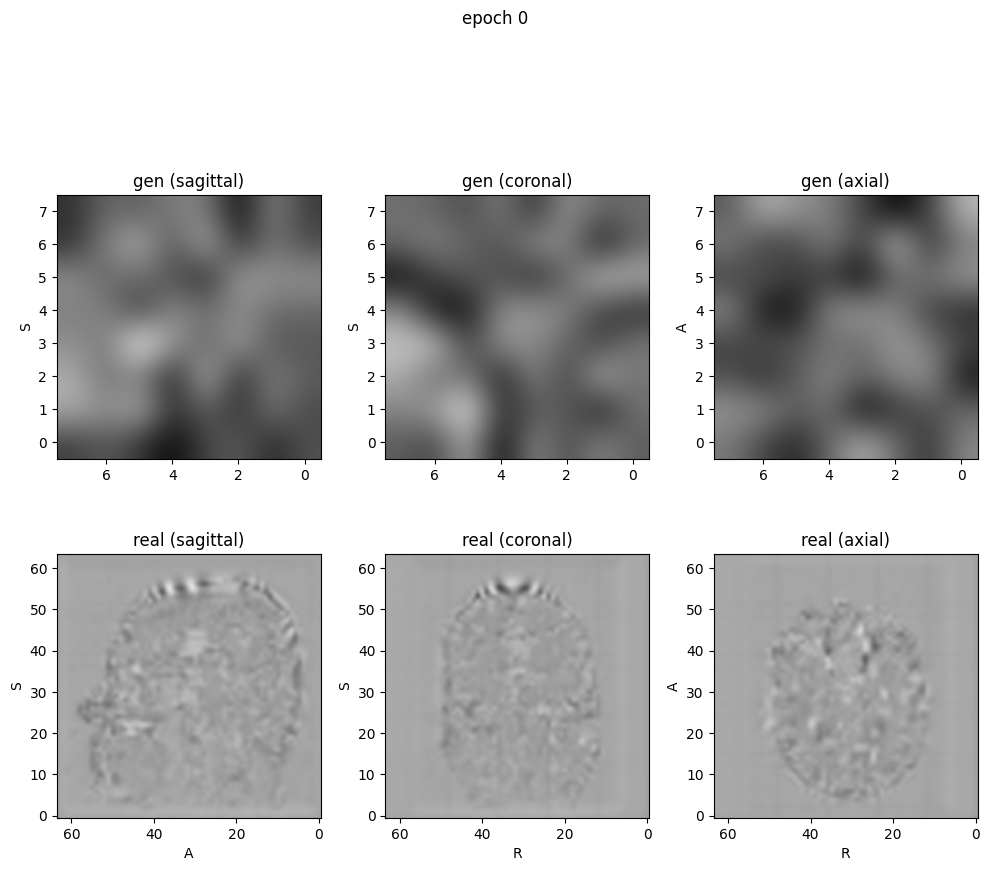

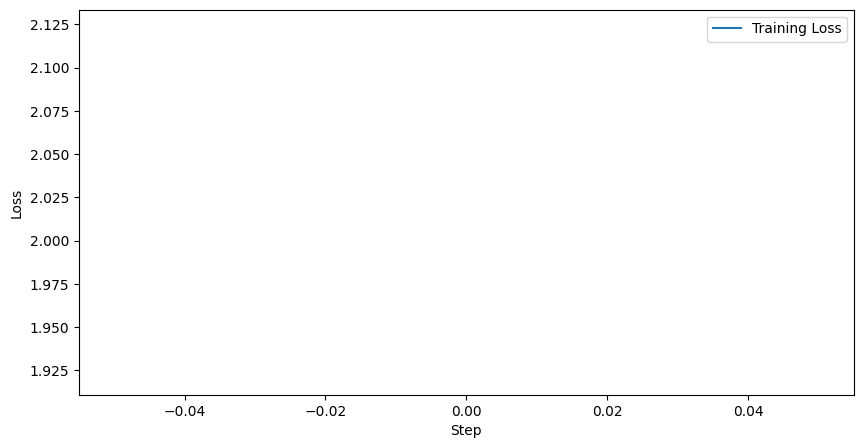

Epoch [1/100], Step [100/1332], Loss: 1.0334


100%|██████████| 25/25 [00:00<00:00, 46.67it/s]


Training interrupted.
Sat Aug 16 21:27:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:CA:00.0 Off |                  N/A |
|100%   82C    P2            348W /  350W |   14550MiB /  24576MiB |    100%      Default |
|                                         |                        |                  N/A |
+-------------------------

In [12]:
if not TRAIN_FINISHED:
    try:
        print("Starting training...")
        # The full training loop
        for epoch in range(100):
            # Set models to training mode at the start of each epoch
            pipeline.train()
            
            for i, batch in enumerate(dataloader):
                # Move data to the correct device
                image = batch["image"].to(device)
                label = batch["labels"].to(device).long()
                label += 1 
                
                optimizer.zero_grad()
                
                # Use autocast for mixed-precision training
                with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                    loss = pipeline(image,label)

                # Scale the loss and backpropagate
                scaler.scale(loss).backward()
                
                # Update the weights
                scaler.step(optimizer)
                
                # Update the scaler for the next iteration
                scaler.update()
                
                # Record loss
                current_loss = loss.item()
                loss_history.append(current_loss)

                # Console logging
                if i % 100 == 0:
                    print(f"Epoch [{epoch+1}/100], Step [{i}/{len(dataloader)}], Loss: {current_loss:.4f}")
                    if epoch % 2 ==0 :
                        with torch.no_grad(), torch.cuda.amp.autocast():
                            pipeline.eval()
                            generated_image = pipeline.sample_latents(label[0:1],cfg=3)
                            subject = tio.Subject(
                                gen = tio.ScalarImage(tensor=generated_image[0].detach().cpu()),
                                real = tio.ScalarImage(tensor=image[0].detach().cpu()),
                            )
                            subject.plot(title=f"epoch {epoch}",vmin=0,vmax=1,figsize=(10,10),cmap_dict={"org":"gray","gen":"gray","diff":"jet"})
                        # plot loss history 
                        plt.figure(figsize=(10, 5))
                        plt.plot(loss_history, label='Training Loss')
                        plt.xlabel('Step')
                        plt.ylabel('Loss')
                        plt.legend()
                        plt.show()
                        torch.save(pipeline.state_dict(),"pipeline.pt")


        print("Training finished.")
        torch.save(pipeline.state_dict(),model_path)
    except KeyboardInterrupt:
        print("Training interrupted.")
        #torch.save(pipeline.state_dict(),"pipeline_interrupted.pt")
        import os 
        os.system("nvidia-smi")
else:
    pipeline.load_state_dict(torch.load(model_path))